# Imports

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Data

## EW2

In [3]:
data_dir = '../classifier/data/all_neurons/'
sorted(os.listdir(data_dir))

['df_all_neurons_2026-02-27-15h.pickle',
 'df_all_neurons_2026-03-14-12h.pickle',
 'df_all_neurons_2026-03-15-09h.pickle',
 'df_all_neurons_2026-03-15-10h.pickle',
 'df_all_neurons_2026-03-16-16h.pickle',
 'df_all_neurons_feat_names_2026-02-27-15h.csv',
 'df_all_neurons_feat_names_2026-03-14-12h.csv',
 'df_all_neurons_feat_names_2026-03-15-09h.csv',
 'df_all_neurons_feat_names_2026-03-15-10h.csv',
 'df_all_neurons_feat_names_2026-03-16-16h.csv']

In [6]:
# version = '2026-03-16-16h' Resource paper
version = '2026-03-16-16h'

df2 = pd.read_pickle(f"{data_dir}/df_all_neurons_{version}.pickle")
print(df2.shape)
print(df2.columns)
df2.head()

(57876, 189)
Index(['ew', 'post_has_cal', 'post_has_axon', 'polar_dens_id1', 'z_dens_id1',
       'z_dens_id3', 'row', 'link', 'nuc', 'status',
       ...
       'norm-path_angle_std', 'norm-path_angle_q5', 'norm-path_angle_q95',
       'norm-log_radius_mean', 'norm-log_radius_median', 'norm-log_radius_std',
       'norm-log_radius_q5', 'norm-log_radius_q95', 'cellclass_pred',
       'cellclass_pred_prob'],
      dtype='object', length=189)


,ew,post_has_cal,post_has_axon,polar_dens_id1,z_dens_id1,z_dens_id3,row,link,nuc,status,...,norm-path_angle_std,norm-path_angle_q5,norm-path_angle_q95,norm-log_radius_mean,norm-log_radius_median,norm-log_radius_std,norm-log_radius_q5,norm-log_radius_q95,cellclass_pred,cellclass_pred_prob
cell,,,,,,,,,,,,,,,,,,,,,
720575940536773811,2,1,0,1,1,3.0,None,None,74386772452474253,ok,...,0.701344,-0.327881,0.881272,0.474599,0.567052,0.204392,0.472040,0.228925,NaN,NaN
720575940536809651,2,1,0,1,1,3.0,None,None,72977679582305120,ok,...,0.247067,0.408253,0.251168,0.610482,0.936878,-0.093848,0.699951,0.118852,NaN,NaN
720575940536909747,2,1,0,1,1,3.0,None,None,75085855689532315,ok,...,0.837542,1.168156,0.615826,1.591194,1.220544,1.907784,0.569287,2.085358,NaN,NaN
720575940537001907,2,1,0,1,1,3.0,None,https://spelunker.cave-explorer.org/#!middleau...,76002092405412019,ok,...,0.843105,-0.256492,0.546991,-0.105444,0.264763,-0.578759,-0.126116,-0.514369,NaN,NaN
720575940537078451,2,1,0,1,1,3.0,None,https://spelunker.cave-explorer.org/#!middleau...,74879834698106440,ok,...,0.343653,0.090593,0.485140,0.954920,0.855773,1.015413,0.821055,0.861857,NaN,NaN


## EW1

In [7]:
from eyewire2_datajoint import utils
from eyewire2_morphological_clustering.utils import labeling

In [8]:
df1_labels = utils.get_df_ew1(add_categories=False, exclude_types=())

ew2_master_dir = "/gpfs01/berens/data/data/Eyewire2/morphologies-ew2/csv/Types/"
daystamp = "2026-01-23"

file_path_mapper = os.path.join(ew2_master_dir, f'Eyewire II Proofread Cells Master List - Cell types and properties {daystamp}.csv')
df1_labels = labeling.clean_labels(
    df1_labels, file_path_mapper=file_path_mapper, celltype_col='ew1_label', remove_suffixes=True, shorten_sbc=True).copy()
df1_labels['ew'] = 1
df1_labels.head()

,ew1_label,ew1_label_merged,ew1_label_short,is_labelled,ew
cell_id,,,,,
70130,OFF-SAC,OFF-SAC,OFF-SAC,True,1
70127,OFF-SAC,OFF-SAC,OFF-SAC,True,1
70147,OFF-SAC,OFF-SAC,OFF-SAC,True,1
70048,OFF-SAC,OFF-SAC,OFF-SAC,True,1
70133,OFF-SAC,OFF-SAC,OFF-SAC,True,1


# Figures

In [9]:
from eyewire2_morphological_clustering.utils.style import set_rc_params

set_rc_params()

In [42]:
fig_dir = f'figures/cellcounts_{version}'
os.makedirs(fig_dir, exist_ok=True)

In [43]:
from eyewire2_morphological_clustering.utils.colors import cellclass2color

## Size comparison

In [15]:
df2['is_AC'] = (df2.cellclass == 'AC') | (df2.cellclass.isna() & (df2.cellclass_pred == 'AC') & (df2.cellclass_pred_prob > 0.8))
df2['is_RGC'] = (df2.cellclass == 'RGC') | (df2.cellclass.isna() & (df2.cellclass_pred == 'RGC') & (df2.cellclass_pred_prob > 0.8))
df2['is_BC'] = (df2.cellclass == 'BC') | (df2.cellclass.isna() & (df2.cellclass_pred == 'BC') & (df2.cellclass_pred_prob > 0.8))

In [16]:
sizes_all = np.concatenate([
    df2[df2['is_AC'] | df2['is_RGC']].hull_diameter.values,
    #df2_bcs[df2_bcs.final_cluster.notnull()].hull_diameter.values,
])

In [19]:
sizes_gcl = np.concatenate([
    df2[(df2['is_AC'] | df2['is_RGC']) & (df2.soma_z_um < 0)].hull_diameter.values,
    #df2_bcs[df2_bcs.final_cluster.notnull()].hull_diameter.values,
])

In [20]:
def make_vline(x, label, ax, line_kws=None, text_kws=None):
    line_kws = dict() if line_kws is None else line_kws
    text_kws = dict() if text_kws is None else text_kws
    ax.axvline(x, label=label, **line_kws)
    ax.text(x, 1.05, label, transform=ax.get_xaxis_transform(),
            ha='center', va='bottom', rotation=90, **text_kws)

In [31]:
df2[df2['is_BC'] & df2['is_labelled']].groupby('celltype').aggregate({'hull_diameter': np.median})

/tmp/ipykernel_3171166/589860299.py:1: FutureWarning: The provided callable <function median at 0x7f46b8b01c60> is currently using SeriesGroupBy.median. In a future version of pandas, the provided callable will be used directly. To keep current behavior pass the string "median" instead.
  df2[df2['is_BC'] & df2['is_labelled']].groupby('celltype').aggregate({'hull_diameter': np.median})


,hull_diameter
celltype,
GluMI,28.21885
RBC,7.69866
XBC,38.24570
t1,23.07395
t2,18.99715
t3a,19.61960
t3b,15.15460
t4,20.86830
t5i,18.72315


In [96]:
i_largest_rgc = df2[df2['is_RGC'] & (df2.post_has_axon) & (df2.status=='Complete') & (df2.ais == 'Annotated')].hull_diameter.idxmax()
df2.loc[i_largest_rgc].name

'720575940568647757'

In [88]:
df2.loc[i_largest_rgc].celltype

'M2'

In [90]:
i_largest_ac = df2[df2['is_AC'] & (~df2.post_has_axon) & (df2.status.isin(['Complete', 'Complete (cutoff)']))].hull_diameter.idxmax()
df2.loc[i_largest_ac].name

'720575940563274172'

In [91]:
df2.loc[i_largest_ac].celltype

'A1'

In [92]:
line_kws = dict(c='r')
text_kws = dict(fontsize=8)

ew1_max = 332.035 # (ConvexHull & "ew=1").fetch('hull_diameter').max()

avg_sac = df2[df2.celltype.isin(['ON SAC', 'OFF SAC'])].hull_diameter.median()
avg_xbc = df2[df2['is_BC'] & df2['is_labelled'] & (df2['celltype'] == 'XBC')].hull_diameter.median()
max_rgc = df2.loc[i_largest_rgc].hull_diameter
max_ac = df2.loc[i_largest_ac].hull_diameter

max_ew2 = 1108.0151710123673

# from eyewire2_datajoint.datajoint.tables.convex_hull import compute_convex_hull_features

# res = compute_convex_hull_features(np.vstack(df2_bcs.hull_points)[:, :2])
# max_ew2 = res['hull_diameter']
# plt.plot(*res['hull_points'].T)
# plt.show()

def plot_size_comparison(ax, sizes):
    ax.hist(sizes, bins=30, color='dimgray')
    ax.set_xlabel('Hull diameter [µm]')
    
    #make_vline(x=avg_xbc, label='average XBC', ax=ax, line_kws=line_kws, text_kws=text_kws)
    make_vline(x=ew1_max, label='largest RGC in EW1', ax=ax, line_kws=line_kws, text_kws=text_kws)
    make_vline(x=avg_sac, label='average SAC', ax=ax, line_kws=line_kws, text_kws=text_kws)
    make_vline(x=max_rgc, label='largest RGC in EW2', ax=ax, line_kws=line_kws, text_kws=text_kws)
    make_vline(x=max_ac, label='largest AC in EW2', ax=ax, line_kws=line_kws, text_kws=text_kws)
    
    make_vline(x=max_ew2, label='max. EW2', ax=ax, line_kws=line_kws, text_kws=text_kws)


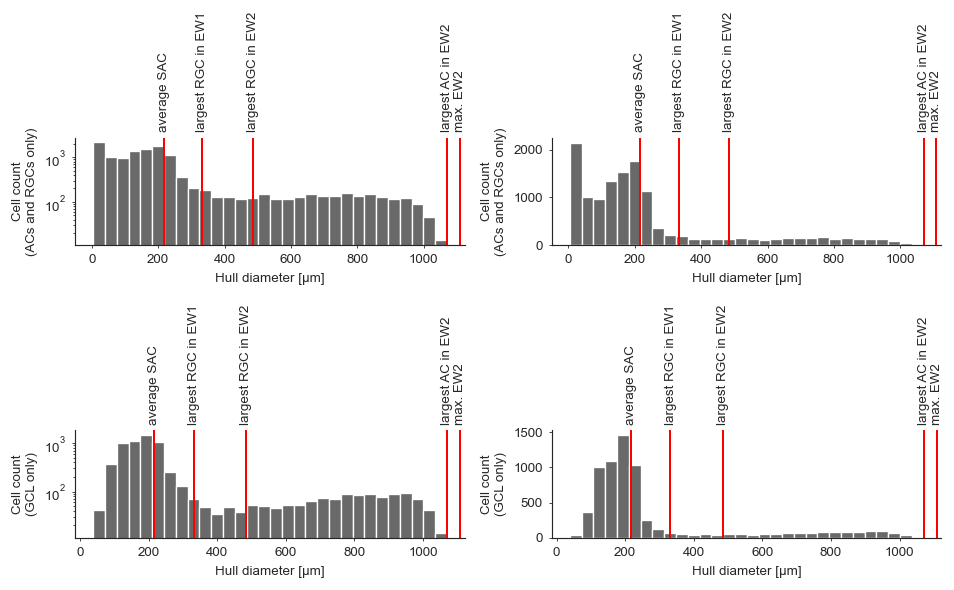

In [93]:
fig, axs = plt.subplot_mosaic(
    """
    AB
    CD
    """,
    figsize=(8, 5)
)

ax = axs['A']
plot_size_comparison(ax, sizes_all)
ax.set_yscale('log')
ax.set_ylabel('Cell count\n(ACs and RGCs only)')

ax = axs['B']
plot_size_comparison(ax, sizes_all)
ax.set_yscale('linear')
ax.set_ylabel('Cell count\n(ACs and RGCs only)')

ax = axs['C']
plot_size_comparison(ax, sizes_gcl)
ax.set_yscale('log')
ax.set_ylabel('Cell count\n(GCL only)')

ax = axs['D']
plot_size_comparison(ax, sizes_gcl)
ax.set_yscale('linear')
ax.set_ylabel('Cell count\n(GCL only)')

plt.tight_layout()
fig.savefig(f'{fig_dir}/cell_sizes.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/cell_sizes.png', dpi=600, bbox_inches='tight')

# Counts

TODO: add more values, compare to EW1, compare to Helmsteadter, compare to Ding?

In [35]:
df1_labels[~df1_labels.ew1_label.isin(['OFF-SAC', 'ON-SAC'])].shape[0]

372

In [36]:
df2.status.unique()

array(['ok', 'Wrong Type', 'Complete', 'Complete (cut off)', None,
       'Wrong type'], dtype=object)

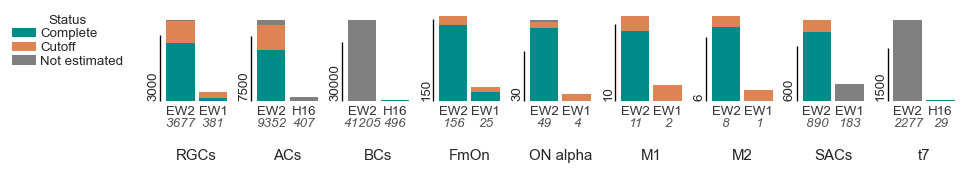

In [50]:
count_dict = {
    # Class   
    "RGCs": {
        'EW2': {
            #'expected': 3_000, #???
            'identified': df2[df2['is_RGC']].shape[0],
            'complete': df2[df2['is_RGC'] & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2['is_RGC'] & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'EW1': {
            'identified': 381,#df1_labels[~df1_labels.ew1_label.isin(['OFF-SAC', 'ON-SAC'])].shape[0],
            'complete': 109,
            'cutoff': 272,
        },
    },

    "ACs": {
        'EW2': {
            #'expected': 10_000, #???
            'identified': df2[df2['is_AC']].shape[0],
            'complete': df2[df2['is_AC'] & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2['is_AC'] & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'H16': {  # https://www.nature.com/articles/nature12346
            'identified': 407, #???
        },
    },

    "BCs": {
        'EW2': {
            #'expected': 50_000, #???
            'identified': df2[df2['is_BC'] & (df2['status'] == 'ok')].shape[0],
        },
        
        'H16': {  # https://www.nature.com/articles/nature12346
            'identified': 496, # ???
            'complete': 496,
        },
    },


    "FmOn": {
        'EW2': {
            'identified': df2[df2.celltype.isin(['F-mini-ON'])].shape[0],
            'complete': df2[df2.celltype.isin(['F-mini-ON']) & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2.celltype.isin(['F-mini-ON']) & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'EW1': {
            'identified': 25,
            'complete': 17,
            'cutoff': 8,
        },
    },
    
    "ON alpha": {
        'EW2': {
            'identified': df2[df2.celltype.isin(['ON alpha'])].shape[0],
            'complete': df2[df2.celltype.isin(['ON alpha']) & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2.celltype.isin(['ON alpha']) & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'EW1': {
            'identified': 4,
            'complete': 0,
            'cutoff': 4,
        },
    },

    "M1": {
        'EW2': {
            'identified': df2[df2.celltype.isin(['M1'])].shape[0],
            'complete': df2[df2.celltype.isin(['M1']) & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2.celltype.isin(['M1']) & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'EW1': {
            'identified': 2,
            'complete': 0,
            'cutoff': 2,
        },
    },

    "M2": {
        'EW2': {
            'identified': df2[df2.celltype.isin(['M2'])].shape[0],
            'complete': df2[df2.celltype.isin(['M2']) & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2.celltype.isin(['M2']) & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'EW1': {  # https://museum.eyewire.org/?neurons=20228
            'identified': 1,
            'complete': 0,
            'cutoff': 1,
        },
    },
    
    "SACs": {
        'EW2': {
            'identified': df2[df2.celltype.isin(['OFF SAC', 'ON SAC'])].shape[0],
            'complete': df2[df2.celltype.isin(['OFF SAC', 'ON SAC']) & (df2.status == 'Complete')].shape[0],
            'cutoff': df2[df2.celltype.isin(['OFF SAC', 'ON SAC']) & (df2.status == 'Complete (cut off)')].shape[0],
        },
        
        'EW1': {
            'identified': df1_labels[df1_labels.ew1_label.isin(['OFF-SAC', 'ON-SAC'])].shape[0],
        },
    },

    
    "t7": {
        'EW2': {
            'identified': df2[df2['is_BC'] & df2['is_labelled'] & (df2['celltype'] == 't7')].shape[0],
        },
        
        'H16': {
            'identified': 29, #???
            'complete': 29,
        },
    },
    
}

############

def get_stack(d):
    identified = d.get('identified', 0)
    complete   = d.get('complete', 0)
    cutoff     = d.get('cutoff', 0)
    expected   = d.get('expected', identified)  # if no expected, no "missing" bar
    other      = max(identified - complete - cutoff, 0)
    missing    = max(expected - identified, 0)
    return {"Complete": complete, "Cutoff": cutoff, "Not estimated": other, "Expected": missing}


def add_scale_bar(ax, x_pos, max_val, n_ticks=3):
    """Draw a vertical scale bar with a single rotated label."""
    import math
    magnitude = 10 ** math.floor(math.log10(max_val)) if max_val > 0 else 1
    scale = round(max_val / magnitude * 0.5) * magnitude / 2
    if scale == 0:
        scale = magnitude / 2

    tick_values = [i * scale for i in range(n_ticks + 1) if i * scale <= max_val * 1.05]
    bar_height = tick_values[-1]

    # Just a vertical line, no tick marks
    ax.plot([x_pos, x_pos], [0, bar_height], color="black", solid_capstyle='butt', lw=0.8, clip_on=False)

    # Single rotated label at the midpoint showing the bar's total height
    ax.text(x_pos - 0.01, 0, f"{int(bar_height)}",
            ha="right", va="bottom", fontsize=8, rotation=90)


def plot_count_dict(count_dict, ax):
    categories = ["Complete", "Cutoff", "Not estimated"]#, "Expected"]
    colors     = {"Complete": "#008B8B", "Cutoff": "#DD8452", "Not estimated": "gray", "Expected": "#C44E52"}
    bar_width  = 0.35
    group_gap  = 0.6
    pair_gap   = 0.05

    cell_classes = list(count_dict.keys())

    positions_ew2, positions_cmp, group_centers, cmp_labels = [], [], [], []
    x = 0
    for cls in cell_classes:
        datasets = count_dict[cls]
        cmp_name = next(k for k in datasets if k != 'EW2')
        cmp_labels.append(cmp_name)

        pos_ew2 = x
        pos_cmp = x + bar_width + pair_gap
        positions_ew2.append(pos_ew2)
        positions_cmp.append(pos_cmp)
        group_centers.append((pos_ew2 + pos_cmp) / 2)
        x += 2 * bar_width + pair_gap + group_gap

    legend_added = set()
    all_totals_ew2 = []
    all_totals_cmp = []

    for i, cls in enumerate(cell_classes):
        ew2_stack = get_stack(count_dict[cls]['EW2'])
        cmp_name  = cmp_labels[i]
        cmp_stack = get_stack(count_dict[cls][cmp_name])

        # Identified total = everything except "Expected (missing)"
        total_ew2 = sum(ew2_stack[c] for c in categories)
        total_cmp = sum(cmp_stack[c] for c in categories)
        all_totals_ew2.append(total_ew2)
        all_totals_cmp.append(total_cmp)

        bottom_ew2 = bottom_cmp = 0
        for cat in categories:
            v_ew2 = ew2_stack[cat]
            v_cmp = cmp_stack[cat]
            color = colors[cat]
            label = cat if cat not in legend_added else None
            if label:
                legend_added.add(cat)

            ax.bar(positions_ew2[i], v_ew2, bar_width, bottom=bottom_ew2,
                   color=color, label=label, edgecolor="none")
            ax.bar(positions_cmp[i], v_cmp, bar_width, bottom=bottom_cmp,
                   color=color, edgecolor="none")

            bottom_ew2 += v_ew2
            bottom_cmp += v_cmp

    # Remove all spines
    for spine in ax.spines.values():
        spine.set_visible(False)

    # Remove yticks
    ax.set_yticks([])

    # Add scale bar (left of first bar)
    y_max = ax.get_ylim()[1]
    scale_x = positions_ew2[0] - bar_width * 0.7
    add_scale_bar(ax, scale_x, y_max * 0.95)

    # x-axis labels (cell class)
    ax.set_xticks(group_centers)
    ax.set_xticklabels(cell_classes, fontsize=9)

    # Sub-labels (EW2 / dataset name) and n= annotations below bars
    y_lim = ax.get_ylim()
    y_range = y_lim[1] - y_lim[0]
    label_offset  = y_range * 0.06
    n_offset      = y_range * 0.20

    for i, (pos_ew2, pos_cmp, cmp_name) in enumerate(zip(positions_ew2, positions_cmp, cmp_labels)):
        ax.text(pos_ew2, -label_offset, "EW2",
                ha="center", va="top", fontsize=8, color="#333333")
        ax.text(pos_cmp, -label_offset, cmp_name,
                ha="center", va="top", fontsize=8, color="#333333")

        # n= below sub-label
        ax.text(pos_ew2, -n_offset, f"{all_totals_ew2[i]}",
                ha="center", va="top", fontsize=8, color="#555555", style="italic")
        ax.text(pos_cmp, -n_offset, f"{all_totals_cmp[i]}",
                ha="center", va="top", fontsize=8, color="#555555", style="italic")

    ax.set_ylim(-n_offset * 2.5, y_lim[1] * 1.05)

###################

fig, axs = plt.subplots(1, len(count_dict), figsize=(7, 1.5))

for i, (k, v) in enumerate(count_dict.items()):
    ax = axs[i]
    ax.tick_params(length=0)
    plot_count_dict({k: v}, ax)

plt.tight_layout(w_pad=0.3)
        
axs.flat[0].legend(title='Status', bbox_to_anchor=(-2, 1), loc="upper left", fontsize=8)

fig.savefig(f'{fig_dir}/cell_counts.svg', bbox_inches='tight')
fig.savefig(f'{fig_dir}/cell_counts.png', dpi=600, bbox_inches='tight')

plt.show()

In [97]:
import shutil

shutil.copytree(fig_dir, f"/gpfs01/euler/data/Resources/Eyewire2/{fig_dir}", dirs_exist_ok=True)

'/gpfs01/euler/data/Resources/Eyewire2/figures/cellcounts_2026-03-16-16h'